<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  0%|          | 0/5 [00:00<?, ?it/s]

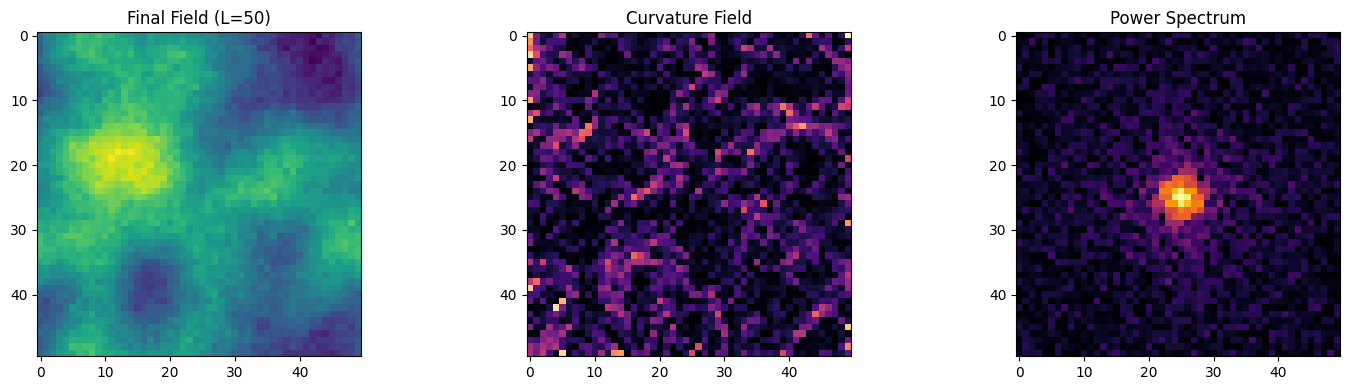

 20%|██        | 1/5 [00:00<00:03,  1.08it/s]

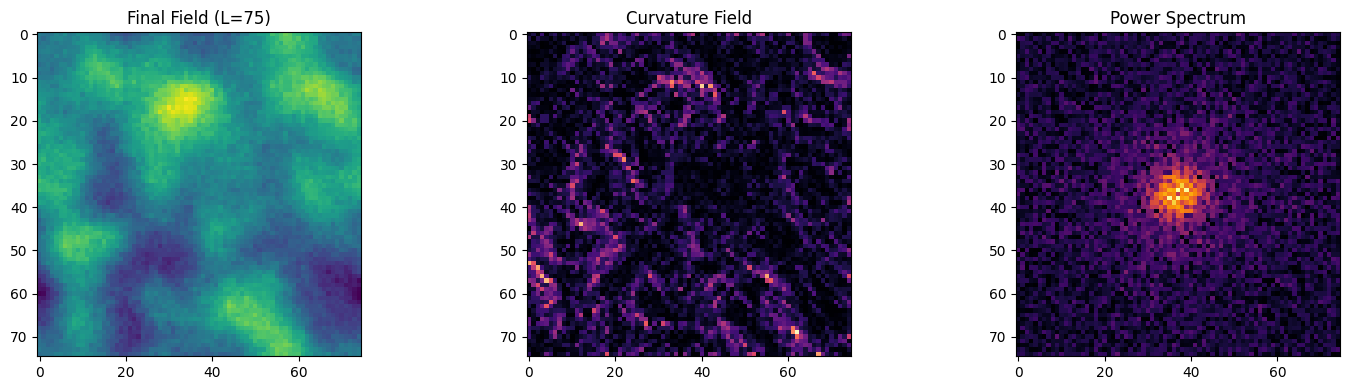

 40%|████      | 2/5 [00:02<00:03,  1.09s/it]

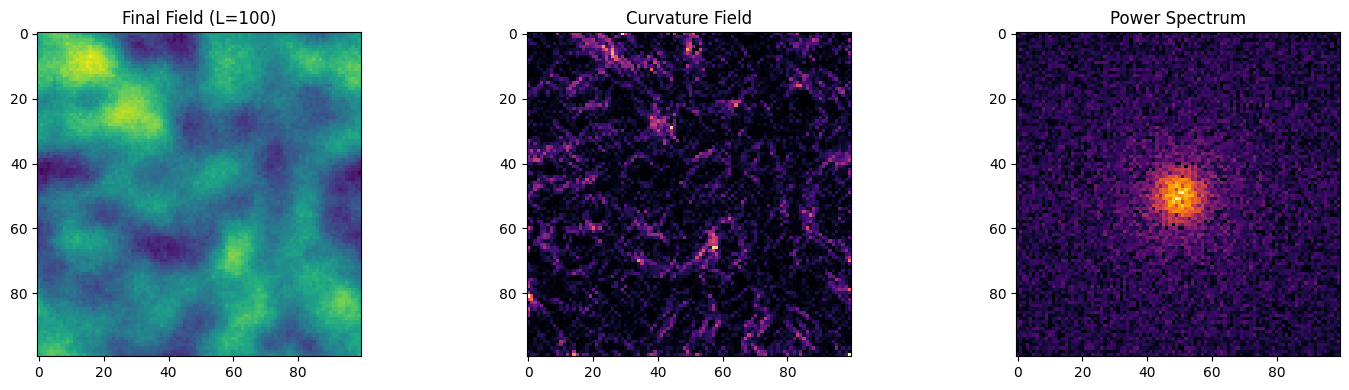

 60%|██████    | 3/5 [00:03<00:02,  1.34s/it]

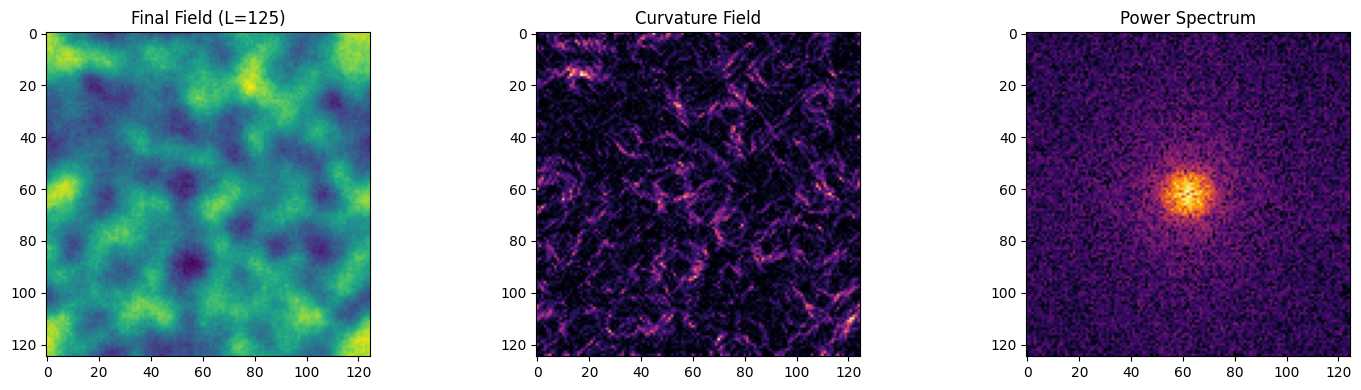

 80%|████████  | 4/5 [00:06<00:01,  1.89s/it]

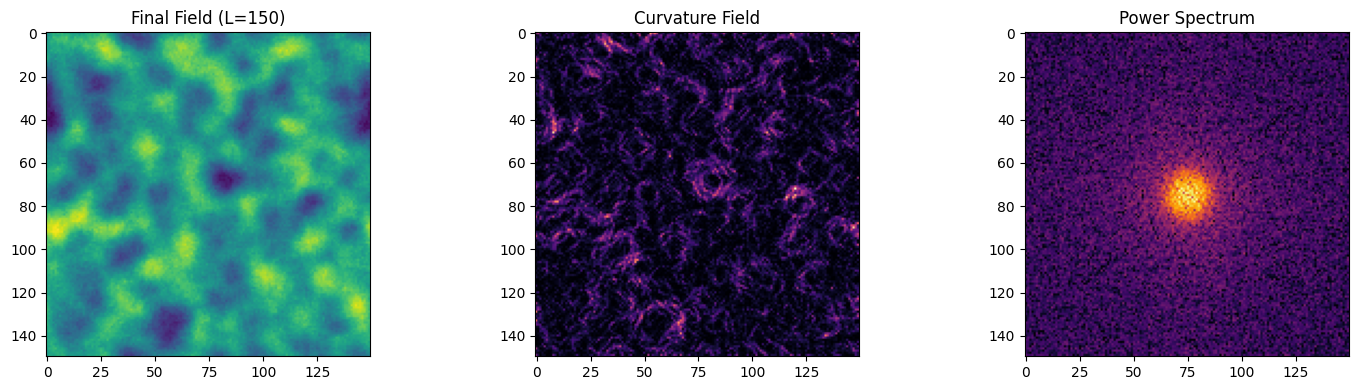

100%|██████████| 5/5 [00:08<00:00,  1.75s/it]

Lattice Size vs Dominant Wavelength:
L =  50 → λ_dom ≈ 2.00
L =  75 → λ_dom ≈ 2.03
L = 100 → λ_dom ≈ 2.00
L = 125 → λ_dom ≈ 2.02
L = 150 → λ_dom ≈ 2.00


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from tqdm import tqdm

# --- Simulation Parameters ---
alpha, beta, gamma, delta = 0.1, 0.01, 0.02, 0.02
T_max = 100
L_values = [50, 75, 100, 125, 150]
seed = 42  # Fixed seed for reproducibility

# --- Simulation Function Placeholder ---
def simulate_field(L, T_max, alpha, beta, gamma, delta, seed):
    np.random.seed(seed)
    Phi = np.random.randn(L, L)
    for t in range(T_max):
        # Replace with actual HES-ATTRACT V2 update rule
        laplacian = (
            np.roll(Phi, 1, axis=0) + np.roll(Phi, -1, axis=0) +
            np.roll(Phi, 1, axis=1) + np.roll(Phi, -1, axis=1) - 4 * Phi
        )
        Phi += alpha * laplacian - beta * Phi + gamma * np.tanh(Phi) + delta * np.random.randn(L, L)
    return Phi

# --- Fourier Analysis ---
def extract_lambda_dom(Phi):
    spectrum = np.abs(fftshift(fft2(Phi)))**2
    center = np.array(spectrum.shape) // 2
    radial = np.mean(spectrum[center[0]-5:center[0]+5, :], axis=0)
    freqs = np.fft.fftfreq(Phi.shape[0])
    peak_idx = np.argmax(radial)
    lambda_dom = 1 / np.abs(freqs[peak_idx])
    return lambda_dom, spectrum

# --- Run Stability003 ---
results = []
for L in tqdm(L_values):
    Phi_final = simulate_field(L, T_max, alpha, beta, gamma, delta, seed)
    lambda_dom, spectrum = extract_lambda_dom(Phi_final)
    results.append((L, lambda_dom))

    # --- Visualization ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].imshow(Phi_final, cmap='viridis')
    axs[0].set_title(f'Final Field (L={L})')
    axs[1].imshow(np.gradient(Phi_final)[0]**2 + np.gradient(Phi_final)[1]**2, cmap='magma')
    axs[1].set_title('Curvature Field')
    axs[2].imshow(np.log1p(spectrum), cmap='inferno')
    axs[2].set_title('Power Spectrum')
    plt.tight_layout()
    plt.show()

# --- Summary Table ---
print("Lattice Size vs Dominant Wavelength:")
for L, lam in results:
    print(f"L = {L:3d} → λ_dom ≈ {lam:.2f}")
